# Liquidity Analysis

This notebook demonstrates how to analyze market liquidity using various metrics:
- Bid-ask spreads
- Market depth
- Price impact
- Liquidity scores

We'll use synthetic market data to illustrate these concepts.

In [2]:
# Import required libraries
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import our custom modules
from utils import generate_price_series, generate_order_book, generate_trade_data
from liquidity import (
    calculate_bid_ask_spread,
    calculate_effective_spread,
    calculate_market_depth,
    calculate_amihud_illiquidity,
    calculate_liquidity_score,
    calculate_relative_spread
)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✓ Libraries loaded successfully')

✓ Libraries loaded successfully


## 1. Generate Synthetic Market Data

First, we'll generate realistic synthetic market data including:
- Price series following geometric Brownian motion
- Order book with bid-ask spreads and depth
- Trade data with volume and direction

In [7]:
# Generate price series
np.random.seed(42)
n_periods = 1000

prices = generate_price_series(
    n_periods=n_periods,
    initial_price=100.0,
    mu=0.0001,
    sigma=0.02,
    seed=42
)

# Generate order book
order_book = generate_order_book(
    prices=prices,
    spread_bps=5.0,
    depth_shares=10000,
    levels=5
)

# Generate trade data
trade_data = generate_trade_data(
    prices=prices,
    avg_volume=1000,
    volume_std=500,
    seed=42
)

print(f'Generated {len(prices)} price points')
print(f'Price range: ${prices.min():.2f} - ${prices.max():.2f}')
print(f'\nOrder book columns: {list(order_book.columns)}')
print(f'\nTrade data shape: {trade_data.shape}')
display(trade_data.head(10))
display(order_book.head(10))

Generated 1000 price points
Price range: $77.10 - $191.28

Order book columns: ['mid_price', 'bid_price', 'ask_price', 'bid_size', 'ask_size', 'bid_price_2', 'ask_price_2', 'bid_size_2', 'ask_size_2', 'bid_price_3', 'ask_price_3', 'bid_size_3', 'ask_size_3', 'bid_price_4', 'ask_price_4', 'bid_size_4', 'ask_size_4', 'bid_price_5', 'ask_price_5', 'bid_size_5', 'ask_size_5']

Trade data shape: (1000, 4)


,price,volume,direction,value
2024-01-01 00:00:00,100.999472,1248,1,126047.340820
2024-01-01 00:01:00,100.744175,930,-1,93692.082885
2024-01-01 00:02:00,102.030058,1323,1,134985.766620
2024-01-01 00:03:00,105.206582,1761,-1,185268.790462
2024-01-01 00:04:00,104.778962,882,1,92415.044625
2024-01-01 00:05:00,104.254226,882,1,91952.227201
2024-01-01 00:06:00,107.601235,1789,1,192498.610002
2024-01-01 00:07:00,109.315888,1383,1,151183.873443
2024-01-01 00:08:00,108.321228,765,-1,82865.739222
2024-01-01 00:09:00,109.502164,1271,1,139177.250286


,mid_price,bid_price,ask_price,bid_size,ask_size,bid_price_2,ask_price_2,bid_size_2,ask_size_2,bid_price_3,...,bid_size_3,ask_size_3,bid_price_4,ask_price_4,bid_size_4,ask_size_4,bid_price_5,ask_price_5,bid_size_5,ask_size_5
2024-01-01 00:00:00,101.008480,100.983227,101.033732,14078,12128,100.957975,101.058984,15135,16834,100.932723,...,9108,5931,100.907471,101.109488,16452,13627,100.882219,101.134740,16079,13949
2024-01-01 00:01:00,100.739621,100.714437,100.764806,13619,16889,100.689252,100.789991,17966,17278,100.664067,...,8020,18128,100.638882,100.840361,10214,13368,100.613697,100.865546,5726,8095
2024-01-01 00:02:00,102.063274,102.037758,102.088790,18616,16029,102.012242,102.114306,8361,15014,101.986726,...,6857,12910,101.961211,102.165337,9712,5138,101.935695,102.190853,14436,5320
2024-01-01 00:03:00,105.230539,105.204231,105.256846,6895,17275,105.177924,105.283154,11583,8273,105.151616,...,13996,19226,105.125308,105.335769,18319,5193,105.099001,105.362077,16652,7321
2024-01-01 00:04:00,104.749364,104.723176,104.775551,11090,7461,104.696989,104.801738,12835,19367,104.670802,...,14136,18861,104.644614,104.854113,5066,8257,104.618427,104.880300,11697,5555
2024-01-01 00:05:00,104.270423,104.244355,104.296490,13508,19291,104.218288,104.322558,16172,9538,104.192220,...,7789,19917,104.166152,104.374693,17478,8235,104.140085,104.400761,16910,9939
2024-01-01 00:06:00,107.627049,107.600142,107.653956,11082,19036,107.573235,107.680862,5006,19497,107.546329,...,19145,11382,107.519422,107.734676,12533,18472,107.492515,107.761583,14257,10432
2024-01-01 00:07:00,109.302656,109.275330,109.329982,5634,16435,109.248005,109.357307,8267,17541,109.220679,...,8875,8406,109.193353,109.411959,9616,5942,109.166028,109.439284,17963,6386
2024-01-01 00:08:00,108.291992,108.264919,108.319065,6925,16551,108.237846,108.346138,11564,13712,108.210773,...,12605,19776,108.183700,108.400284,18277,9620,108.156627,108.427357,5282,9763
2024-01-01 00:09:00,109.484437,109.457066,109.511808,7056,5685,109.429694,109.539179,14783,14168,109.402323,...,14802,13339,109.374952,109.593921,6140,17071,109.347581,109.621292,6081,16239


## 2. Visualize Market Data

Let's visualize the generated data to understand the market structure.

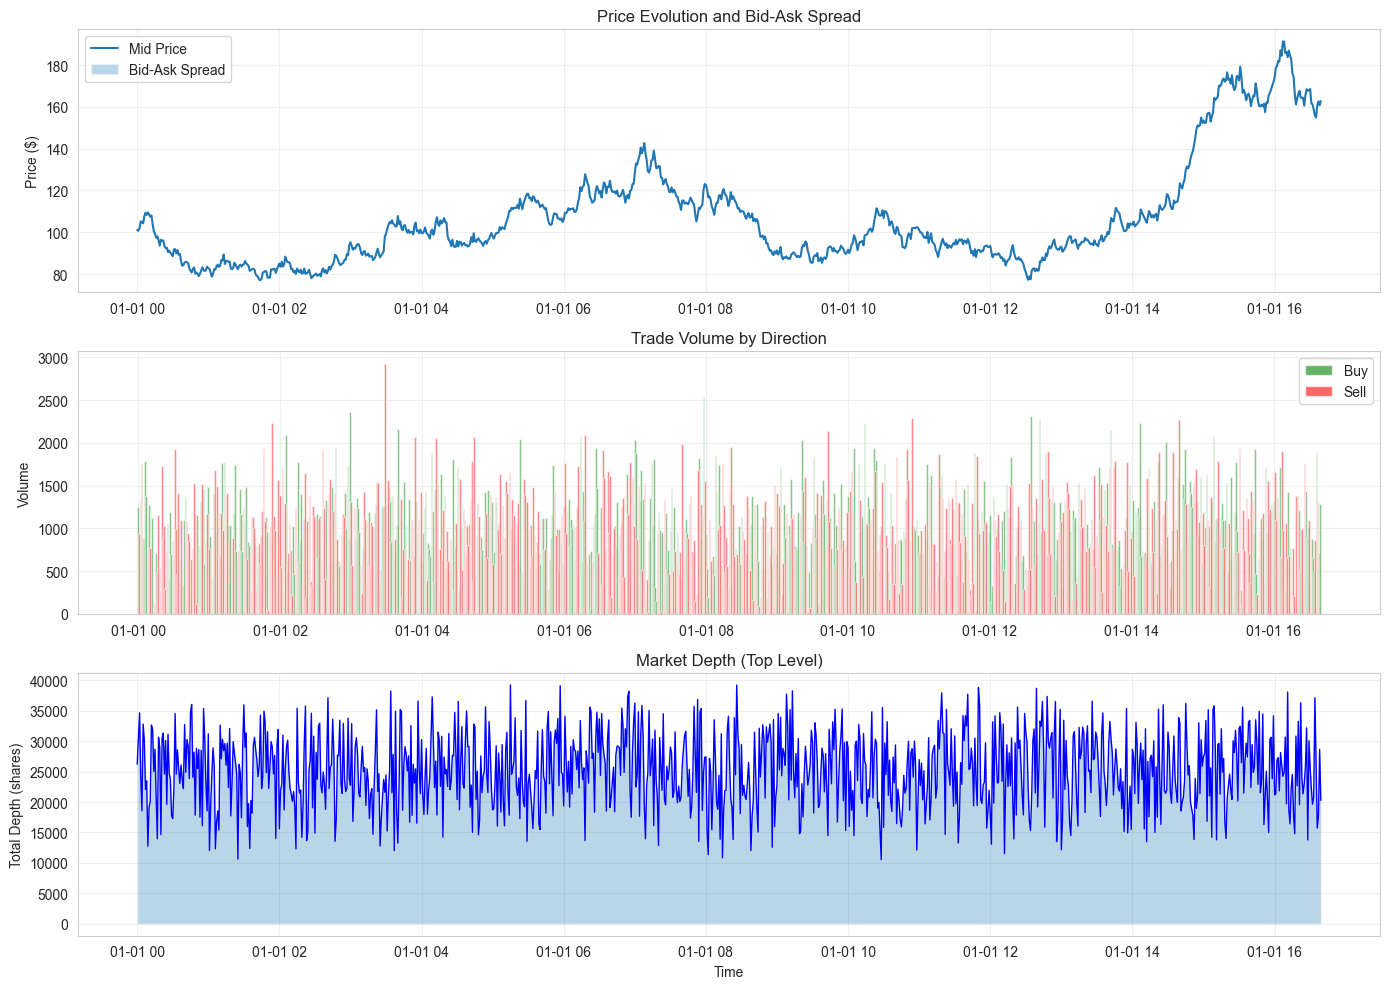

✓ Market data visualization complete


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Price and Order Book
ax1 = axes[0]
ax1.plot(order_book.index, order_book['mid_price'], label='Mid Price', linewidth=1.5)
ax1.fill_between(order_book.index, 
                  order_book['bid_price'], 
                  order_book['ask_price'],
                  alpha=0.3, label='Bid-Ask Spread')
ax1.set_ylabel('Price ($)')
ax1.set_title('Price Evolution and Bid-Ask Spread')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Trading Volume
ax2 = axes[1]
buy_trades = trade_data[trade_data['direction'] == 1]
sell_trades = trade_data[trade_data['direction'] == -1]
ax2.bar(buy_trades.index, buy_trades['volume'], width=0.001, alpha=0.6, color='green', label='Buy')
ax2.bar(sell_trades.index, sell_trades['volume'], width=0.001, alpha=0.6, color='red', label='Sell')
ax2.set_ylabel('Volume')
ax2.set_title('Trade Volume by Direction')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Market Depth
ax3 = axes[2]
total_depth = order_book['bid_size'] + order_book['ask_size']
ax3.plot(order_book.index, total_depth, color='blue', linewidth=1)
ax3.fill_between(order_book.index, 0, total_depth, alpha=0.3)
ax3.set_ylabel('Total Depth (shares)')
ax3.set_xlabel('Time')
ax3.set_title('Market Depth (Top Level)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('✓ Market data visualization complete')

## 3. Calculate Bid-Ask Spread Metrics

The bid-ask spread is the most fundamental liquidity metric.

In [9]:
# Calculate different types of spreads
spread_absolute = calculate_bid_ask_spread(
    order_book['bid_price'],
    order_book['ask_price'],
    spread_type='absolute'
)

spread_bps = calculate_bid_ask_spread(
    order_book['bid_price'],
    order_book['ask_price'],
    spread_type='bps'
)

spread_pct = calculate_bid_ask_spread(
    order_book['bid_price'],
    order_book['ask_price'],
    spread_type='percentage'
)

# Calculate relative spread
rel_spread = calculate_relative_spread(
    order_book['bid_price'],
    order_book['ask_price']
)

# Summary statistics
print('Bid-Ask Spread Statistics:')
print('=' * 50)
print(f'Average Absolute Spread: ${spread_absolute.mean():.4f}')
print(f'Average Spread (bps): {spread_bps.mean():.2f}')
print(f'Average Spread (%): {spread_pct.mean():.4f}%')
print(f'\nSpread Range (bps): {spread_bps.min():.2f} - {spread_bps.max():.2f}')
print(f'Spread Std Dev (bps): {spread_bps.std():.2f}')

Bid-Ask Spread Statistics:
Average Absolute Spread: $0.0534
Average Spread (bps): 5.00
Average Spread (%): 0.0500%

Spread Range (bps): 5.00 - 5.00
Spread Std Dev (bps): 0.00


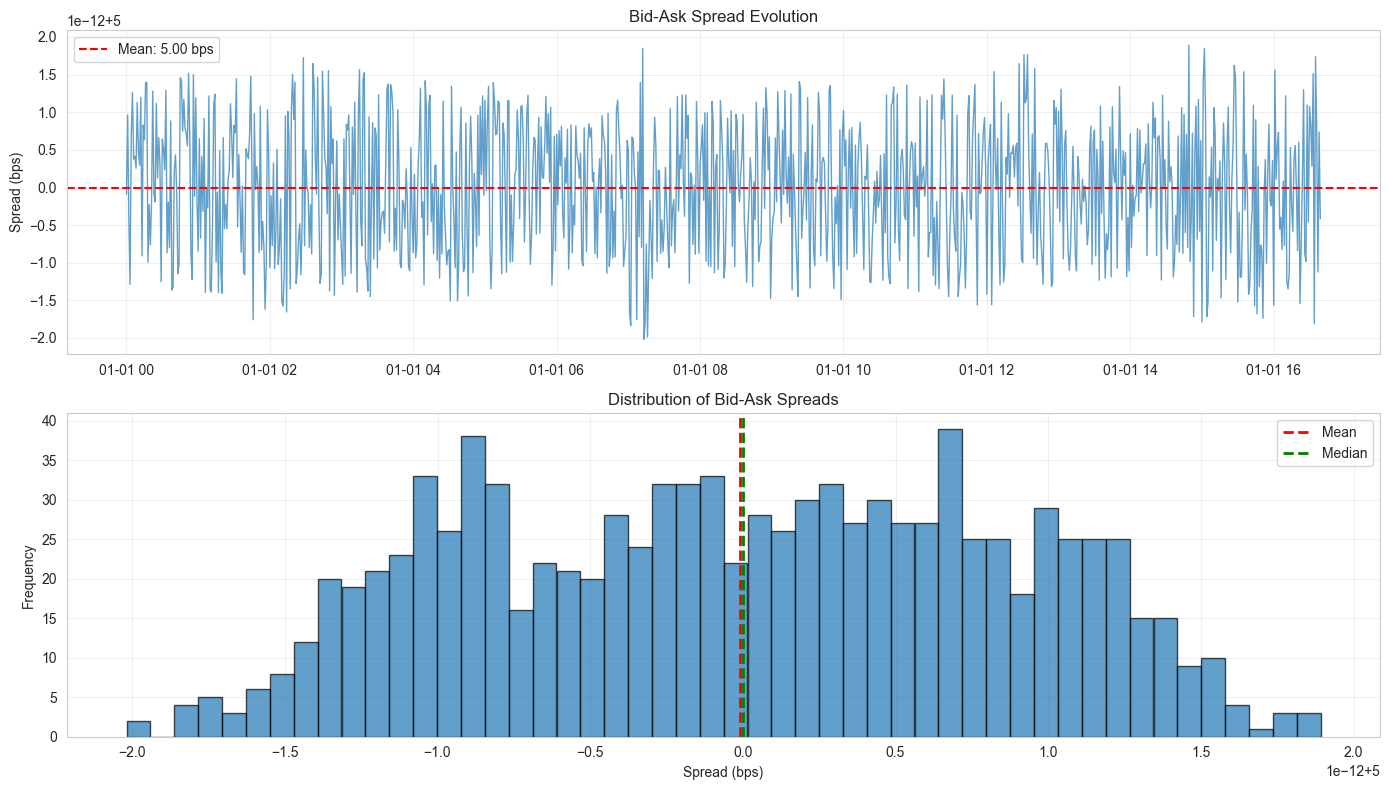

In [10]:
# Visualize spread evolution
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Spread in basis points
axes[0].plot(spread_bps.index, spread_bps, linewidth=1, alpha=0.7)
axes[0].axhline(spread_bps.mean(), color='r', linestyle='--', label=f'Mean: {spread_bps.mean():.2f} bps')
axes[0].set_ylabel('Spread (bps)')
axes[0].set_title('Bid-Ask Spread Evolution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution of spreads
axes[1].hist(spread_bps, bins=50, alpha=0.7, edgecolor='black')
axes[1].axvline(spread_bps.mean(), color='r', linestyle='--', linewidth=2, label='Mean')
axes[1].axvline(spread_bps.median(), color='g', linestyle='--', linewidth=2, label='Median')
axes[1].set_xlabel('Spread (bps)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Bid-Ask Spreads')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Market Depth Analysis

Market depth measures the quantity available at different price levels.

In [11]:
# Calculate total depth at top level
top_level_depth = order_book['bid_size'] + order_book['ask_size']

print('Market Depth Statistics:')
print('=' * 50)
print(f'Average Total Depth (top level): {top_level_depth.mean():,.0f} shares')
print(f'Min Depth: {top_level_depth.min():,.0f} shares')
print(f'Max Depth: {top_level_depth.max():,.0f} shares')
print(f'\nAverage Bid Size: {order_book["bid_size"].mean():,.0f} shares')
print(f'Average Ask Size: {order_book["ask_size"].mean():,.0f} shares')

Market Depth Statistics:
Average Total Depth (top level): 25,209 shares
Min Depth: 10,540 shares
Max Depth: 39,222 shares

Average Bid Size: 12,698 shares
Average Ask Size: 12,511 shares


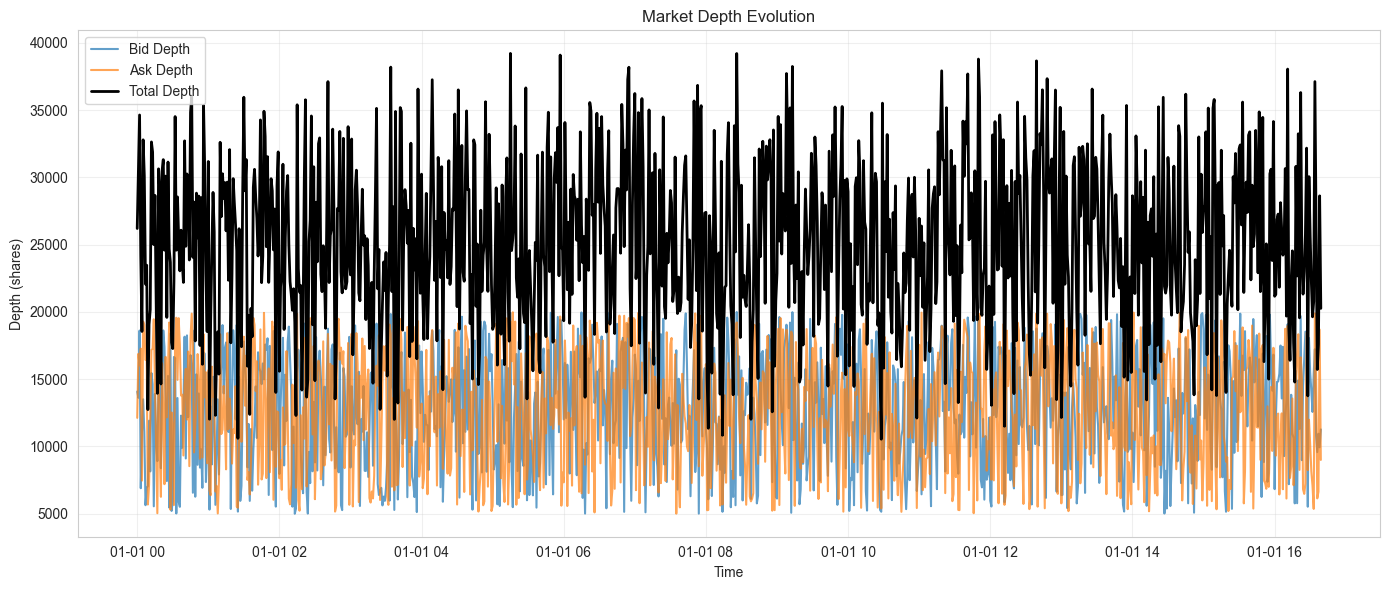

In [12]:
# Visualize depth over time
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(order_book.index, order_book['bid_size'], label='Bid Depth', alpha=0.7)
ax.plot(order_book.index, order_book['ask_size'], label='Ask Depth', alpha=0.7)
ax.plot(order_book.index, top_level_depth, label='Total Depth', linewidth=2, color='black')

ax.set_xlabel('Time')
ax.set_ylabel('Depth (shares)')
ax.set_title('Market Depth Evolution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Amihud Illiquidity Measure

The Amihud (2002) measure captures how much prices move per unit of trading volume.

In [13]:
# Calculate returns
returns = prices.pct_change().dropna()

# Calculate Amihud illiquidity
amihud_rolling = calculate_amihud_illiquidity(
    returns.reindex(trade_data.index, method='nearest'),
    trade_data['volume'],
    window=20
)

amihud_overall = calculate_amihud_illiquidity(
    returns.reindex(trade_data.index, method='nearest'),
    trade_data['volume'],
    window=None
)

print('Amihud Illiquidity Measure:')
print('=' * 50)
print(f'Overall Amihud: {amihud_overall:.8f}')
print(f'\nRolling Amihud (20-period window):')
print(f'Mean: {amihud_rolling.mean():.8f}')
print(f'Std: {amihud_rolling.std():.8f}')
print(f'\nNote: Higher values indicate lower liquidity')

Amihud Illiquidity Measure:
Overall Amihud: 0.00005167

Rolling Amihud (20-period window):
Mean: 0.00005101
Std: 0.00005937

Note: Higher values indicate lower liquidity


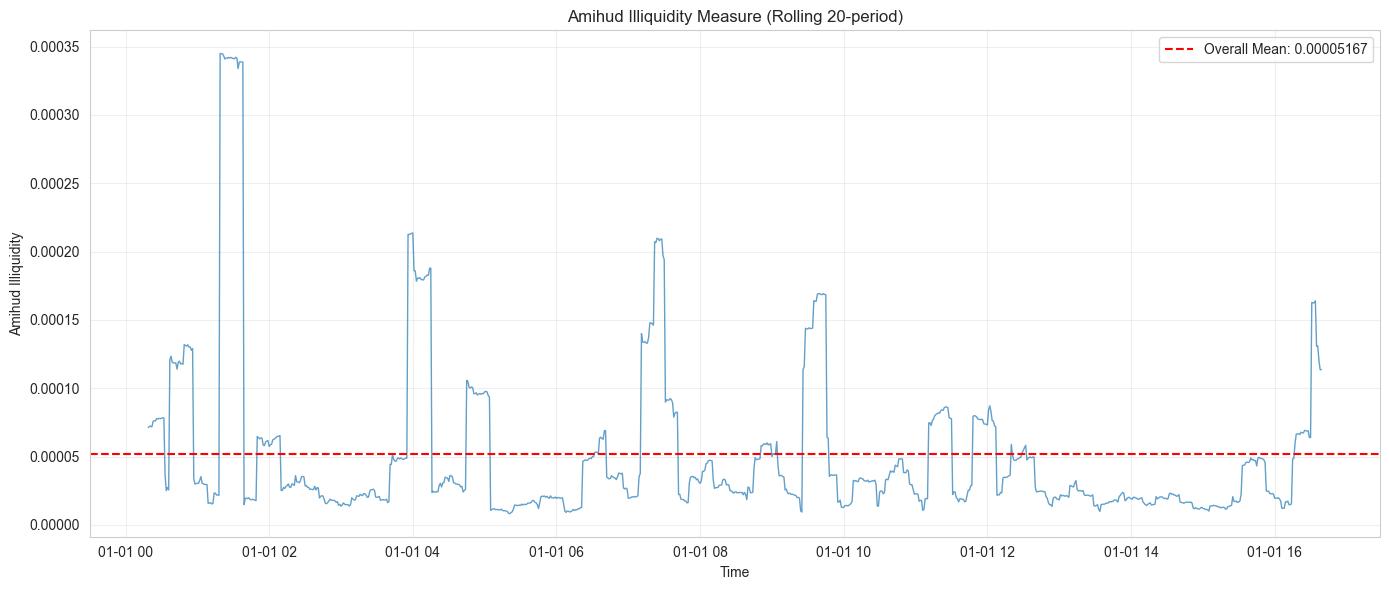

In [14]:
# Visualize Amihud measure
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(amihud_rolling.index, amihud_rolling, linewidth=1, alpha=0.7)
ax.axhline(amihud_overall, color='r', linestyle='--', 
           label=f'Overall Mean: {amihud_overall:.8f}')

ax.set_xlabel('Time')
ax.set_ylabel('Amihud Illiquidity')
ax.set_title('Amihud Illiquidity Measure (Rolling 20-period)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Composite Liquidity Score

Combine multiple metrics into a single liquidity score.

In [15]:
# Calculate composite liquidity score
liquidity_score = calculate_liquidity_score(
    bid_ask_spread=spread_absolute,
    depth=top_level_depth,
    volume=trade_data['volume'].reindex(order_book.index, method='nearest').fillna(method='ffill'),
    normalize=True
)

print('Composite Liquidity Score (0-100):')
print('=' * 50)
print(f'Mean Score: {liquidity_score.mean():.2f}')
print(f'Std Dev: {liquidity_score.std():.2f}')
print(f'Range: {liquidity_score.min():.2f} - {liquidity_score.max():.2f}')
print(f'\nInterpretation: Higher scores indicate better liquidity')

Composite Liquidity Score (0-100):
Mean Score: 52.96
Std Dev: 11.30
Range: 14.27 - 82.95

Interpretation: Higher scores indicate better liquidity


/var/folders/qq/3ztd8n_52dvcv5_12w9h0f2r0000gn/T/ipykernel_54611/860299653.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  volume=trade_data['volume'].reindex(order_book.index, method='nearest').fillna(method='ffill'),


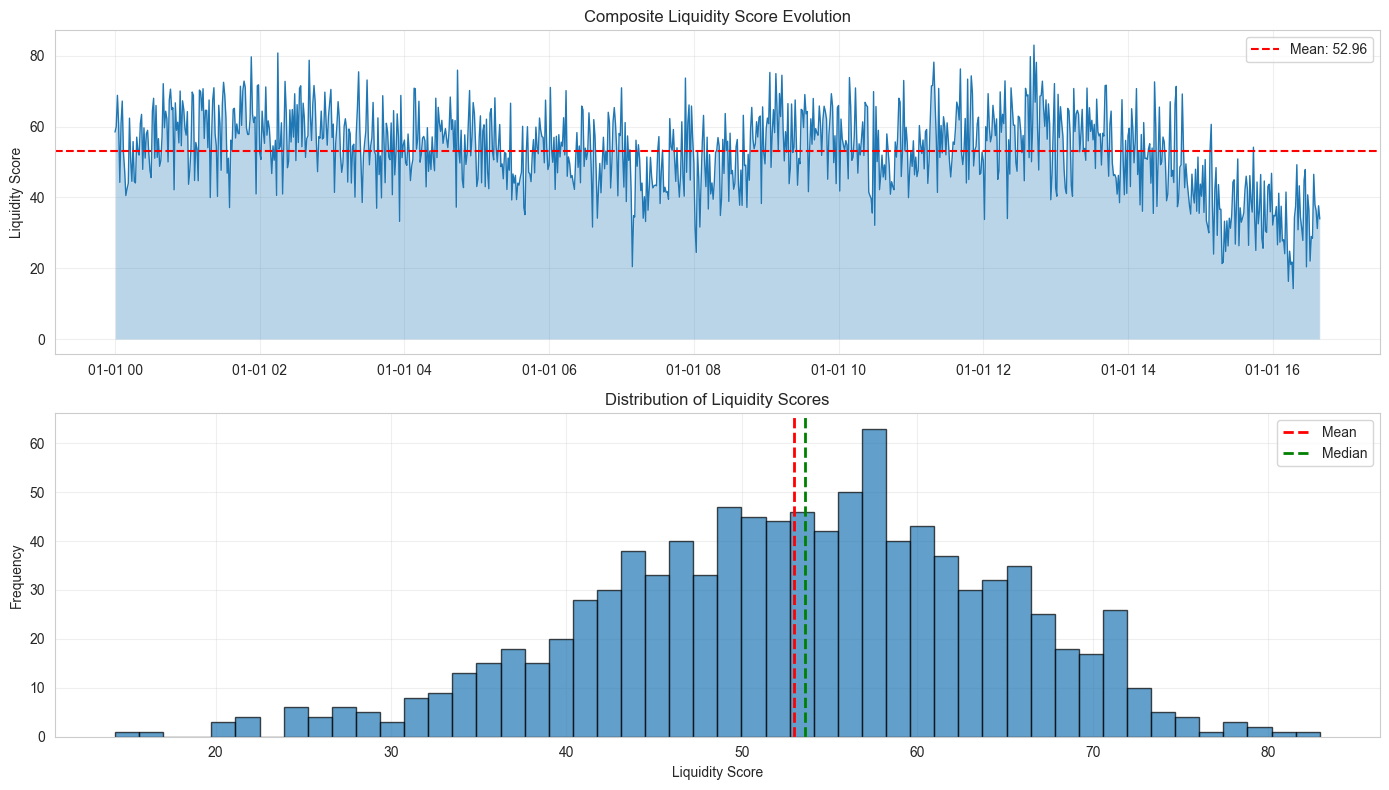

In [16]:
# Visualize liquidity score
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Time series
axes[0].plot(liquidity_score.index, liquidity_score, linewidth=1)
axes[0].axhline(liquidity_score.mean(), color='r', linestyle='--', 
                label=f'Mean: {liquidity_score.mean():.2f}')
axes[0].fill_between(liquidity_score.index, 0, liquidity_score, alpha=0.3)
axes[0].set_ylabel('Liquidity Score')
axes[0].set_title('Composite Liquidity Score Evolution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution
axes[1].hist(liquidity_score, bins=50, alpha=0.7, edgecolor='black')
axes[1].axvline(liquidity_score.mean(), color='r', linestyle='--', linewidth=2, label='Mean')
axes[1].axvline(liquidity_score.median(), color='g', linestyle='--', linewidth=2, label='Median')
axes[1].set_xlabel('Liquidity Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Liquidity Scores')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Summary and Key Insights

Let's create a comprehensive summary of all liquidity metrics.

In [17]:
# Create summary DataFrame
summary_stats = pd.DataFrame({
    'Metric': [
        'Average Bid-Ask Spread (bps)',
        'Average Market Depth (shares)',
        'Average Trade Volume (shares)',
        'Amihud Illiquidity',
        'Liquidity Score (0-100)',
        'Price Volatility (%)'
    ],
    'Value': [
        f'{spread_bps.mean():.2f}',
        f'{top_level_depth.mean():,.0f}',
        f'{trade_data["volume"].mean():,.0f}',
        f'{amihud_overall:.8f}',
        f'{liquidity_score.mean():.2f}',
        f'{returns.std() * 100:.4f}'
    ],
    'Interpretation': [
        'Lower is better (cost of immediacy)',
        'Higher is better (more liquidity)',
        'Higher is better (more trading activity)',
        'Lower is better (less price impact)',
        'Higher is better (overall liquidity)',
        'Lower is better (more stable prices)'
    ]
})

print('\nLiquidity Metrics Summary:')
print('=' * 80)
print(summary_stats.to_string(index=False))
print('=' * 80)


Liquidity Metrics Summary:
                       Metric      Value                           Interpretation
 Average Bid-Ask Spread (bps)       5.00      Lower is better (cost of immediacy)
Average Market Depth (shares)     25,209        Higher is better (more liquidity)
Average Trade Volume (shares)      1,014 Higher is better (more trading activity)
           Amihud Illiquidity 0.00005167      Lower is better (less price impact)
      Liquidity Score (0-100)      52.96     Higher is better (overall liquidity)
         Price Volatility (%)     1.9630     Lower is better (more stable prices)


## 8. Correlation Analysis

Examine relationships between different liquidity metrics.

/var/folders/qq/3ztd8n_52dvcv5_12w9h0f2r0000gn/T/ipykernel_54611/268679323.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  'volume': trade_data['volume'].reindex(order_book.index, method='nearest').fillna(method='ffill'),


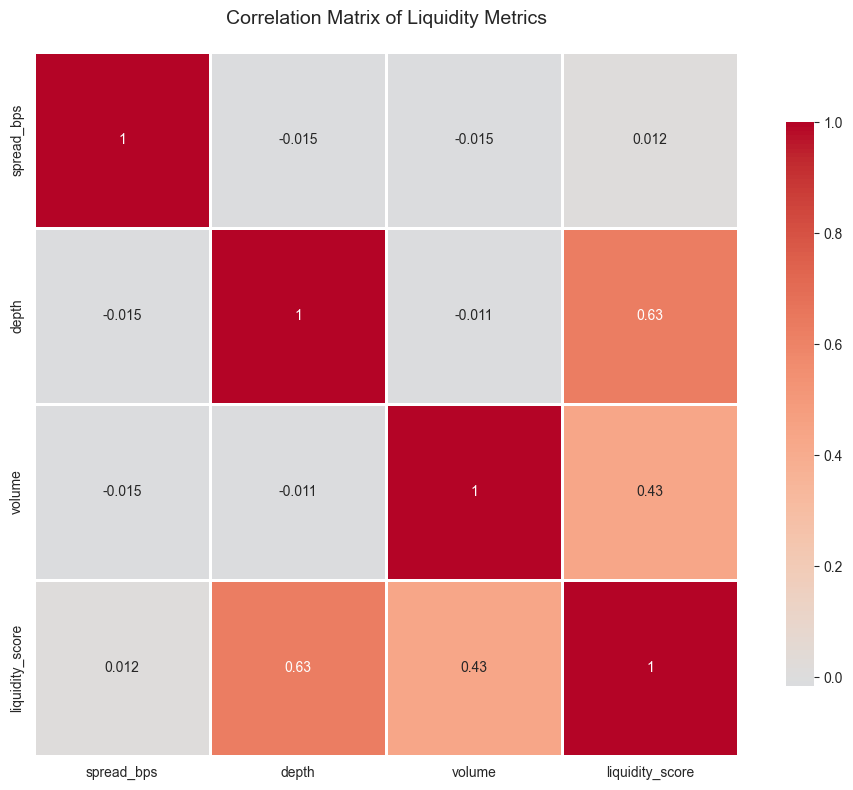


Key Correlations:
spread_bps vs depth: -0.015
spread_bps vs volume: -0.015
spread_bps vs liquidity_score: 0.012
depth vs volume: -0.011
depth vs liquidity_score: 0.628
volume vs liquidity_score: 0.434


In [18]:
# Combine metrics into DataFrame
metrics_df = pd.DataFrame({
    'spread_bps': spread_bps,
    'depth': top_level_depth,
    'volume': trade_data['volume'].reindex(order_book.index, method='nearest').fillna(method='ffill'),
    'liquidity_score': liquidity_score
})

# Calculate correlation matrix
correlation_matrix = metrics_df.corr()

# Visualize correlations
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
ax.set_title('Correlation Matrix of Liquidity Metrics', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print('\nKey Correlations:')
print('=' * 50)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        col1 = correlation_matrix.columns[i]
        col2 = correlation_matrix.columns[j]
        corr = correlation_matrix.iloc[i, j]
        print(f'{col1} vs {col2}: {corr:.3f}')

## Conclusion

In this notebook, we've explored various liquidity metrics:

1. **Bid-Ask Spread**: Fundamental measure of transaction costs
2. **Market Depth**: Quantity available at different price levels
3. **Amihud Illiquidity**: Price impact per unit of volume
4. **Composite Score**: Combined metric incorporating multiple dimensions

These metrics are essential for:
- Assessing execution costs
- Choosing optimal execution strategies
- Risk management
- Market quality analysis

### Next Steps
- Explore Transaction Cost Analysis in notebook 02
- Apply these metrics to real market data
- Investigate intraday patterns in liquidity